In [42]:
# ============================================================================
# IMPORTS
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                             accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, mean_absolute_percentage_error)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

import json
import os
import random
from datetime import datetime

In [43]:
# ============================================================================
# SETUP AND CONFIGURATION
# ============================================================================

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# Create directories for saving models and reports
os.makedirs('outputs', exist_ok=True)
os.makedirs('outputs/models', exist_ok=True)
os.makedirs('outputs/reports', exist_ok=True)


In [44]:
data = pd.read_csv("Data/vmCloud_data.csv")

print("\nFirst 5 rows:")
display(data.head())

print("\nLast 5 rows:")
display(data.tail())


First 5 rows:


,vm_id,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status
0,c5215826-6237-4a33-9312-72c1df909881,2023-01-25 09:10:54,54.881350,78.950861,164.775973,287.808986,7527.0,69.345575,0.553589,network,medium,waiting
1,29690bc6-1f34-403b-b509-a1ecb1834fb8,2023-01-26 04:46:34,71.518937,29.901883,NaN,362.273569,5348.0,41.396040,0.349856,io,high,completed
2,2e55abc3-5bad-46cb-b445-a577f5e9bf2a,2023-01-13 23:39:47,NaN,92.709195,203.674847,231.467903,5483.0,24.602549,0.796277,io,medium,completed
3,e672e32f-c134-4fbc-992b-34eb63bef6bf,2023-02-09 11:45:49,54.488318,88.100960,NaN,195.639954,5876.0,16.456670,0.529511,compute,high,completed
4,f38b8b50-6926-4533-be4f-89ad11624071,2023-06-14 08:27:26,42.365480,NaN,NaN,359.451537,3361.0,55.307992,0.351907,NaN,medium,waiting



Last 5 rows:


,vm_id,timestamp,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency,task_type,task_priority,task_status
23666,1d8be5a9-7280-466b-9c29-67e2e78b8d9d,NaN,55.977327,NaN,964.914457,225.237257,NaN,18.318278,0.255978,network,high,waiting
23667,NaN,NaN,61.837055,24.291308,547.554664,NaN,9174.0,1.916920,0.096871,io,NaN,running
23668,a443bf10-9d9f-4c49-99b8-dd767f039aeb,2023-05-01 02:09:35,NaN,86.207920,237.700687,443.435749,800.0,74.775102,NaN,compute,high,running
23669,016f5e63-c259-406e-8683-94fef1aca748,2023-04-04 12:42:05,10.108700,83.583420,671.435117,NaN,2743.0,66.620411,0.362640,compute,low,completed
23670,59f,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
# ============================================================================
#DATA INSPECTION AND OVERVIEW
# ============================================================================

# Basic information about the dataset
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nDataset shape: {data.shape}")
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")

print("\nColumn names and data types:")
print("-" * 60)
print(data.dtypes)

print("\nMissing values per column:")
print("-" * 60)
print(data.isnull().sum())

# Duplicates
duplicates = data.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Numeric columns
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns: {len(numeric_cols)}")
print(numeric_cols)

# Categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns: {len(categorical_cols)}")
print(categorical_cols)

DATASET OVERVIEW

Dataset shape: (23671, 12)
Rows: 23671, Columns: 12

Column names and data types:
------------------------------------------------------------
vm_id                         object
timestamp                     object
cpu_usage                    float64
memory_usage                 float64
network_traffic              float64
power_consumption            float64
num_executed_instructions    float64
execution_time               float64
energy_efficiency            float64
task_type                     object
task_priority                 object
task_status                   object
dtype: object

Missing values per column:
------------------------------------------------------------
vm_id                        2405
timestamp                    2472
cpu_usage                    2329
memory_usage                 2318
network_traffic              2422
power_consumption            2388
num_executed_instructions    2421
execution_time               2401
energy_efficiency   

In [46]:
# ============================================================================
# DESCRIPTIVE STATISTICS
# ============================================================================

# Descriptive statistics for numeric columns
desc_stats = data[numeric_cols].describe()

print("DESCRIPTIVE STATISTICS:")
print("=" * 60)
display(desc_stats)
print("-" * 60)
print(f"Variance:")
print(data[numeric_cols].var().round(2))

print(f"\nSkewness (measure of distribution asymmetry):")
print(data[numeric_cols].skew().round(2))

print(f"\nKurtosis (measure of tail heaviness):")
print(data[numeric_cols].kurtosis().round(2))


# Save to CSV (for report)
desc_stats.to_csv('outputs/descriptive_statistics.csv')


DESCRIPTIVE STATISTICS:


,cpu_usage,memory_usage,network_traffic,power_consumption,num_executed_instructions,execution_time,energy_efficiency
count,21342.000000,21353.000000,21249.000000,21283.000000,21250.000000,21270.000000,21269.000000
mean,49.765682,49.876658,501.455966,250.157223,4988.551624,49.703930,0.503128
std,29.009758,28.908043,288.488041,143.700706,2872.286108,28.803588,0.290149
min,0.007245,0.001615,0.143941,0.022323,0.000000,0.002654,0.000009
25%,24.585455,25.077224,253.782169,125.556152,2476.000000,24.921030,0.250553
50%,49.808132,50.139928,501.099034,251.891419,4982.000000,49.692923,0.506571
75%,74.908664,74.988669,752.139620,374.088596,7460.750000,74.534438,0.753543
max,99.997795,99.992070,999.987020,499.919104,9999.000000,99.988922,0.999974


------------------------------------------------------------
Variance:
cpu_usage                        841.57
memory_usage                     835.67
network_traffic                83225.35
power_consumption              20649.89
num_executed_instructions    8250027.48
execution_time                   829.65
energy_efficiency                  0.08
dtype: float64

Skewness (measure of distribution asymmetry):
cpu_usage                    0.01
memory_usage                -0.01
network_traffic             -0.01
power_consumption           -0.01
num_executed_instructions    0.01
execution_time               0.01
energy_efficiency           -0.01
dtype: float64

Kurtosis (measure of tail heaviness):
cpu_usage                   -1.21
memory_usage                -1.20
network_traffic             -1.20
power_consumption           -1.19
num_executed_instructions   -1.19
execution_time              -1.20
energy_efficiency           -1.21
dtype: float64


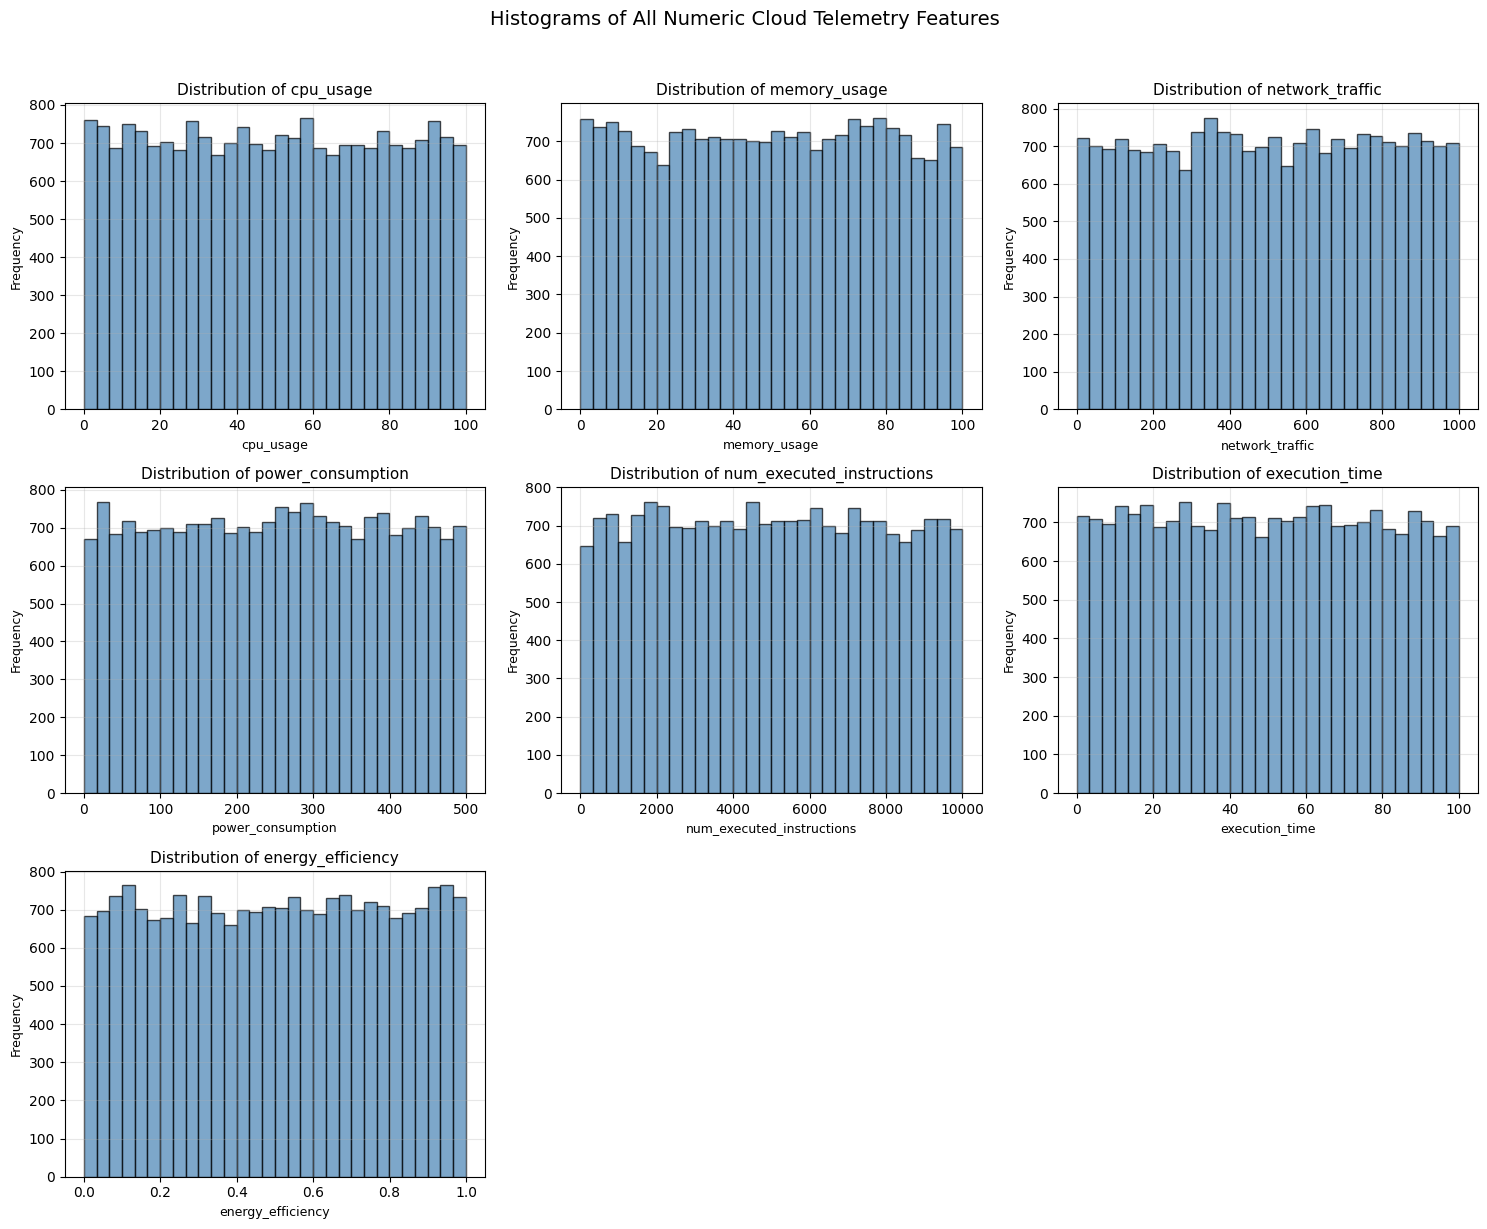

✓ Histograms displayed for all 7 numeric features


In [47]:
# ============================================================================
# VISUALISATION 1 - HISTOGRAMS (All Numeric Columns)
# ============================================================================

# Get all numeric columns except ID-like columns
exclude_cols = ['vm_id']  # ID/identifier columns
numeric_features = [col for col in numeric_cols if col not in exclude_cols]

# Calculate grid size (2 columns, as many rows as needed)
n_features = len(numeric_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() if n_rows > 1 else [axes]  # Handle single row case

for i, feature in enumerate(numeric_features):
    ax = axes[i]
    ax.hist(data[feature].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(f'Distribution of {feature}', fontsize=11)
    ax.set_xlabel(feature, fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for i in range(len(numeric_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Histograms of All Numeric Cloud Telemetry Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print(f"✓ Histograms displayed for all {n_features} numeric features")

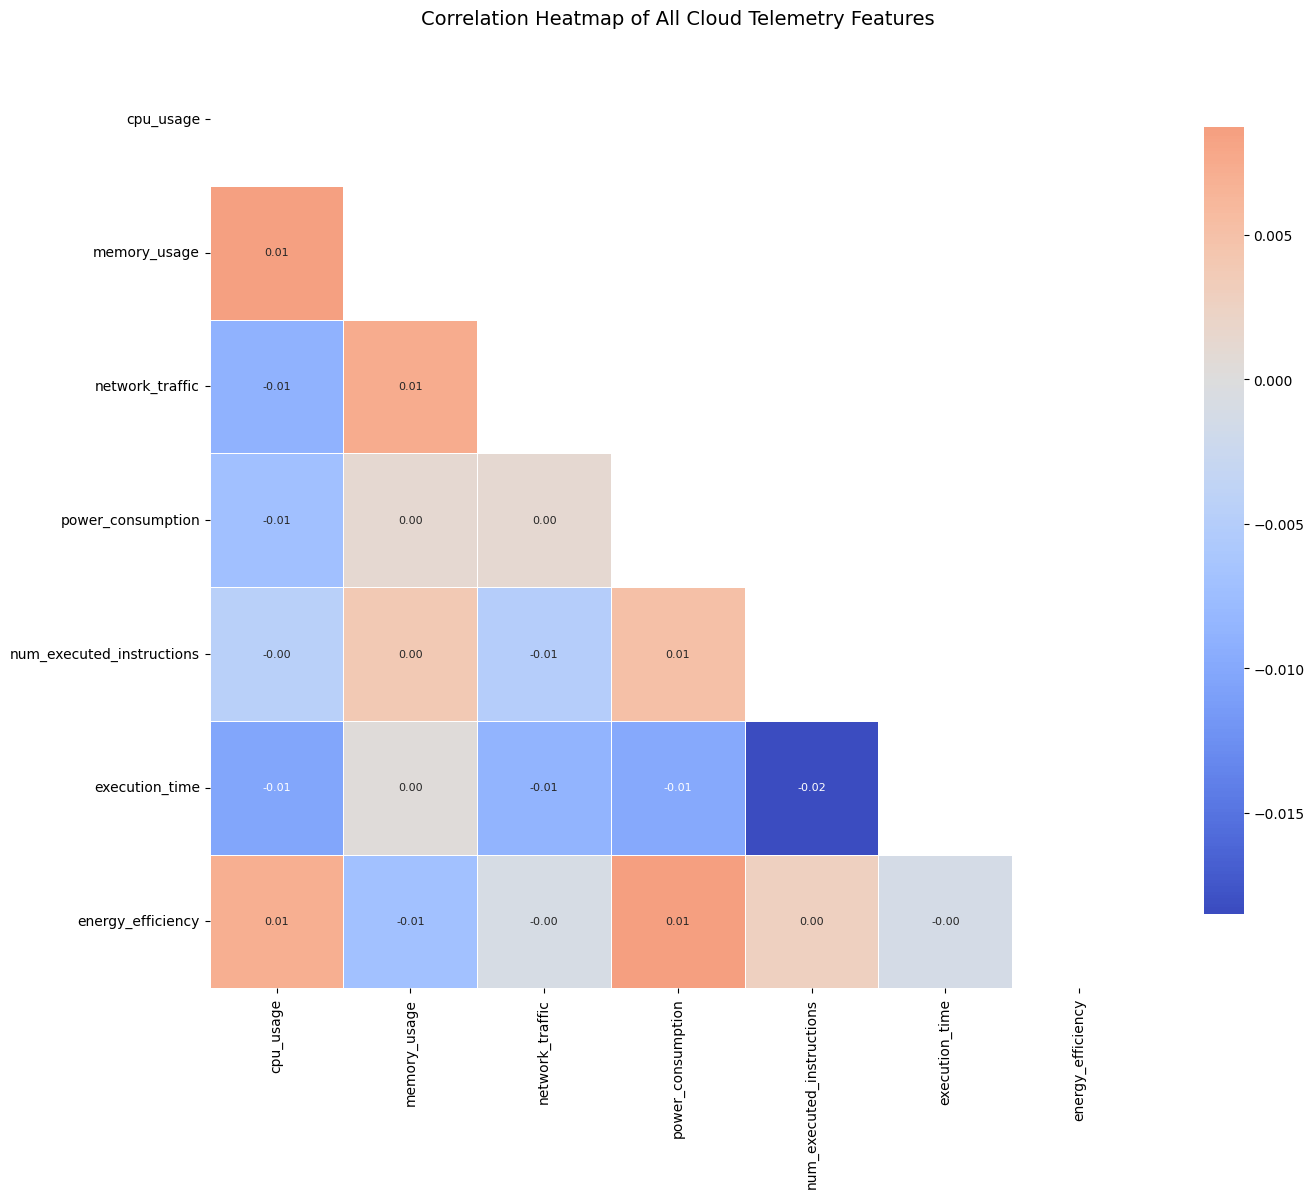


MULTICOLLINEAR FEATURES (|correlation| > 0.7):
------------------------------------------------------------
  No multicollinear features detected


In [48]:
# ============================================================================
# VISUALISATION 2 - CORRELATION HEATMAP (All Numeric Columns)
# ============================================================================

# Correlation matrix for all numeric columns
corr_matrix = data[numeric_features].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={'size': 8})

plt.title('Correlation Heatmap of All Cloud Telemetry Features', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Multicollinear features (|correlation| > 0.7)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j],
                                   corr_matrix.iloc[i, j]))

print("\nMULTICOLLINEAR FEATURES (|correlation| > 0.7):")
print("-" * 60)
if high_corr_pairs:
    for pair in high_corr_pairs:
        print(f"  {pair[0]} ↔ {pair[1]}: {pair[2]:.3f}")
else:
    print("  No multicollinear features detected")


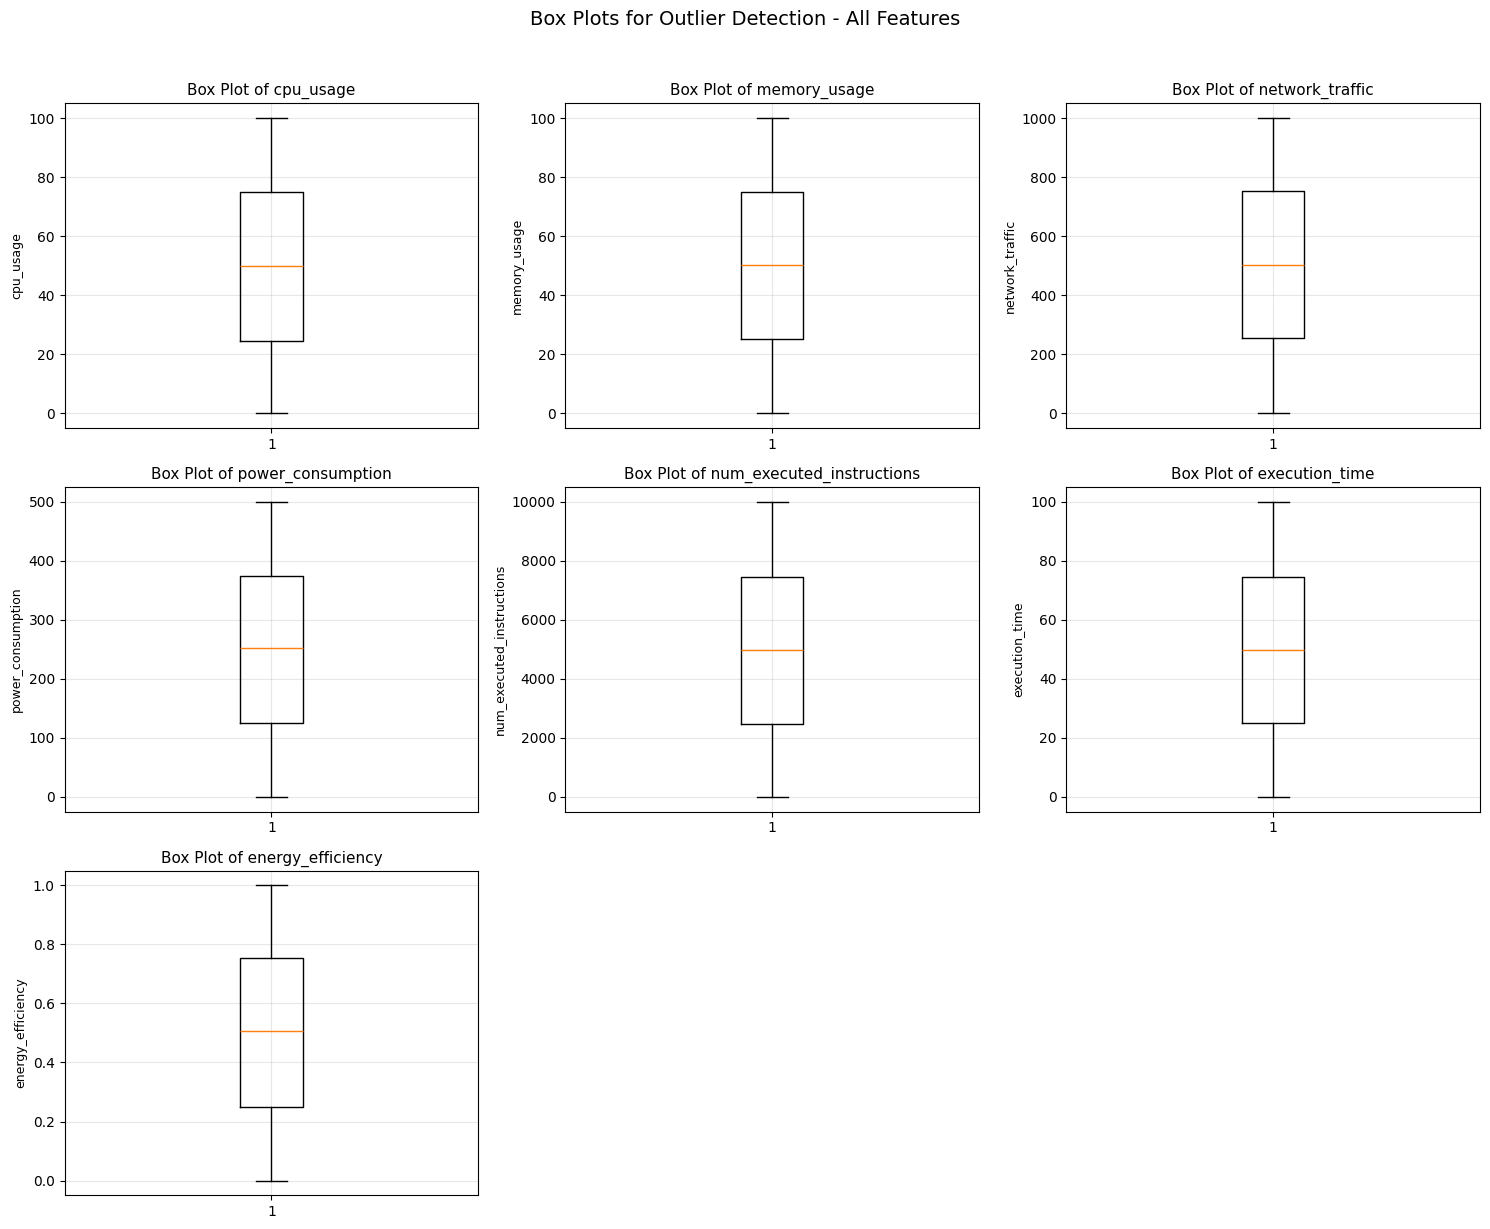


OUTLIER DETECTION (IQR Method):
------------------------------------------------------------
                  Feature  Outlier Count  Percentage
                cpu_usage              0         0.0
             memory_usage              0         0.0
          network_traffic              0         0.0
        power_consumption              0         0.0
num_executed_instructions              0         0.0
           execution_time              0         0.0
        energy_efficiency              0         0.0

✓ Box plots displayed for all 7 numeric features


In [49]:
# ============================================================================
# VISUALISATION 3 - BOX PLOTS
# ============================================================================

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() if n_rows > 1 else [axes]

for i, feature in enumerate(numeric_features):
    ax = axes[i]
    ax.boxplot(data[feature].dropna())
    ax.set_title(f'Box Plot of {feature}', fontsize=11)
    ax.set_ylabel(feature, fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for i in range(len(numeric_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Box Plots for Outlier Detection - All Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Detect outliers using IQR method for all features
outlier_count = {}
outlier_percentage = {}
for col in numeric_features:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data[col] < Q1 - 1.5*IQR) | (data[col] > Q3 + 1.5*IQR)]
    outlier_count[col] = len(outliers)
    outlier_percentage[col] = (len(outliers) / len(data)) * 100

print("\nOUTLIER DETECTION (IQR Method):")
print("-" * 60)
outlier_df = pd.DataFrame({
    'Feature': list(outlier_count.keys()),
    'Outlier Count': list(outlier_count.values()),
    'Percentage': list(outlier_percentage.values())
})
print(outlier_df.to_string(index=False))
print(f"\n✓ Box plots displayed for all {n_features} numeric features")

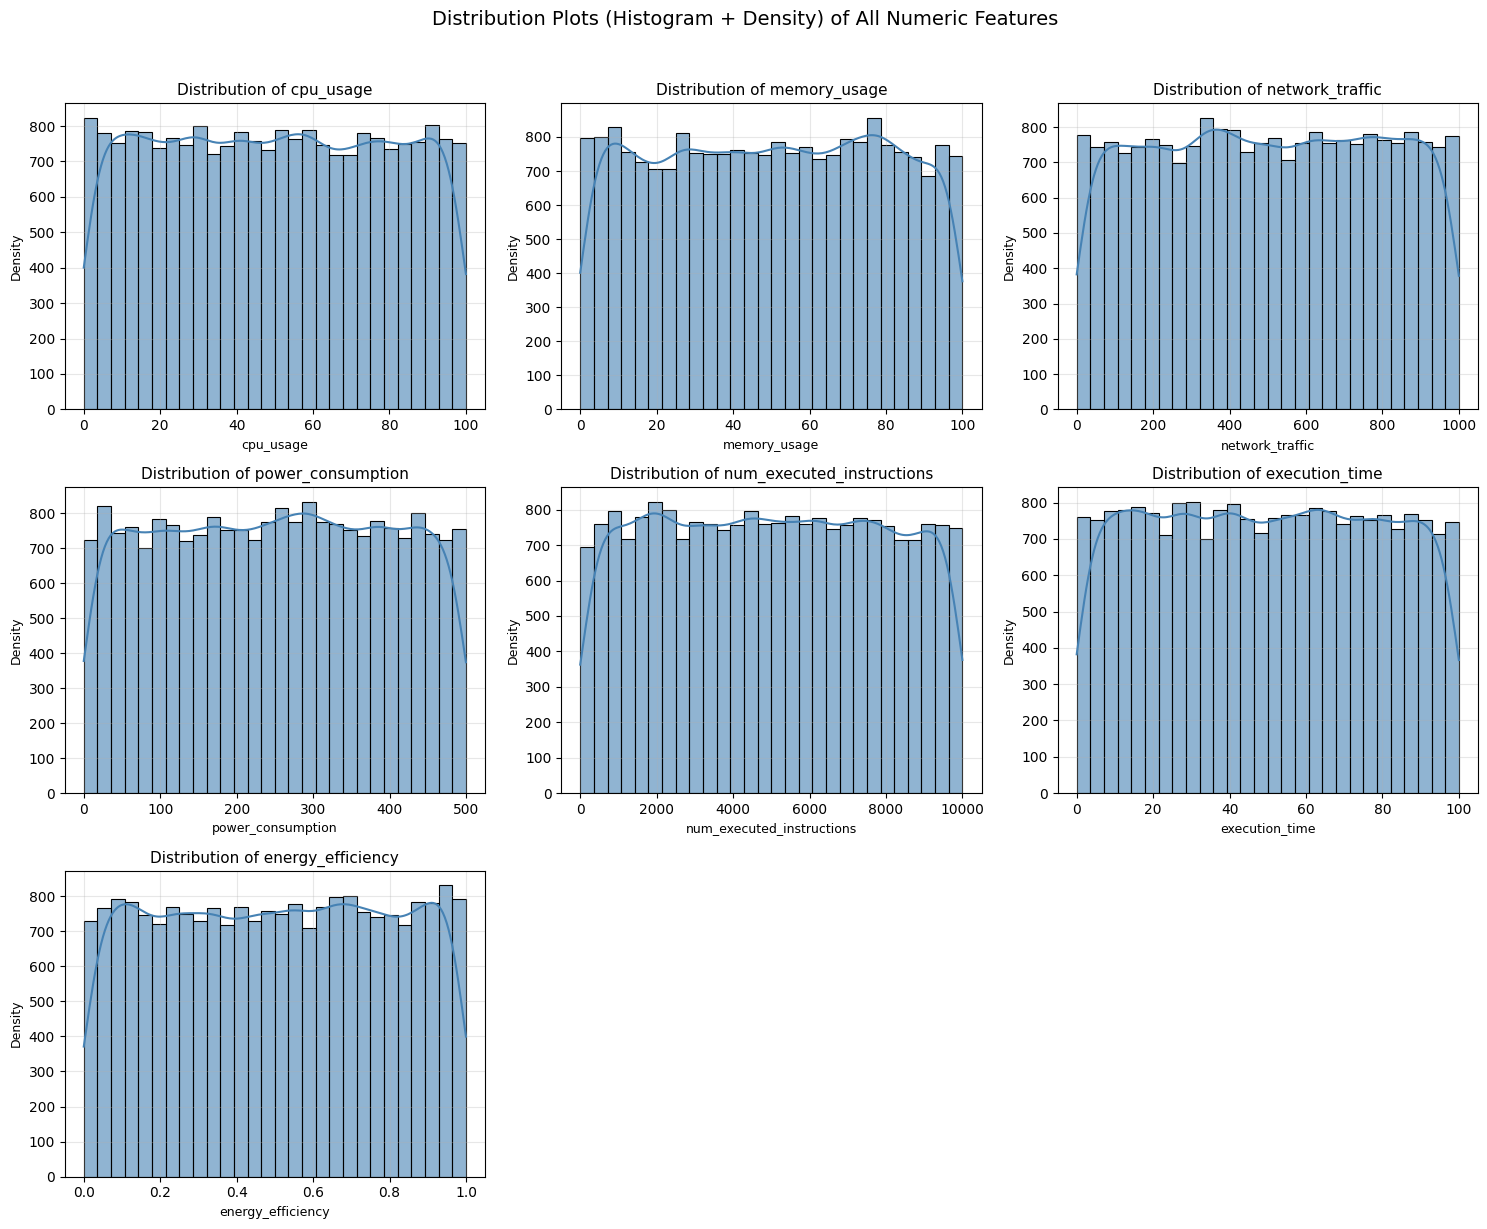

✓ Distribution plots displayed for all 7 numeric features


In [50]:
# ============================================================================
# VISUALISATION 4 - DISTRIBUTION PLOTS (Density + Histogram)
# ============================================================================

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() if n_rows > 1 else [axes]

for i, feature in enumerate(numeric_features):
    ax = axes[i]
    # Plot histogram with density curve
    sns.histplot(data[feature].dropna(), kde=True, ax=ax, color='steelblue', alpha=0.6)
    ax.set_title(f'Distribution of {feature}', fontsize=11)
    ax.set_xlabel(feature, fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for i in range(len(numeric_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Distribution Plots (Histogram + Density) of All Numeric Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print(f"✓ Distribution plots displayed for all {n_features} numeric features")

<Figure size 1200x1000 with 0 Axes>

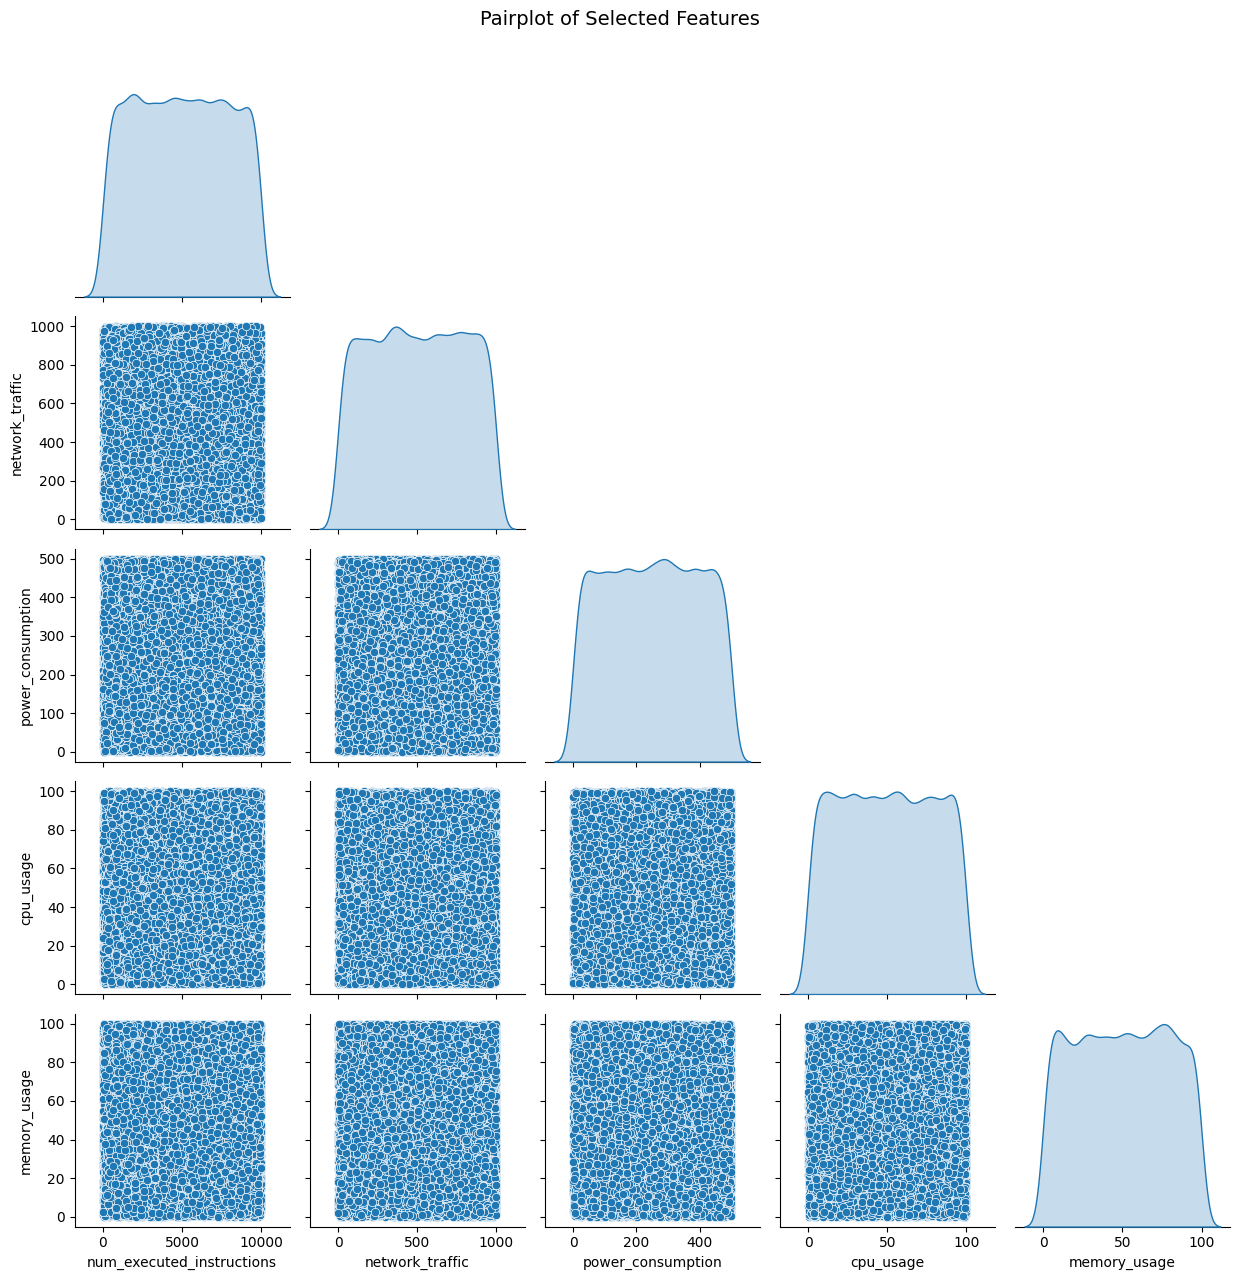

✓ Pairplot displayed for 5 features


In [51]:
# ============================================================================
# VISUALISATION 5 - PAIRPLOT (Selected Features)
# ============================================================================

# choosing few features to avoid overcrowding, by getting the highest variance
if len(numeric_features) > 5:
    # Select features with highest variance
    variances = data[numeric_features].var()
    selected_features = variances.nlargest(5).index.tolist()
else:
    selected_features = numeric_features

if len(selected_features) > 1:
    fig = plt.figure(figsize=(12, 10))
    sns.pairplot(data[selected_features], diag_kind='kde', corner=True)
    plt.suptitle('Pairplot of Selected Features', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()
    print(f"✓ Pairplot displayed for {len(selected_features)} features")
else:
    print("Not enough features for pairplot")

In [52]:
# ============================================================================
# DATA PREPARATION FOR SUPERVISED LEARNING
# ============================================================================

# Define feature columns (exclude non-numeric and ID columns)
exclude_cols = ['vm_id', 'timestamp']  # Exclude ID and timestamp columns
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

# Identify potential target variables, But since we don't have explicit target columns, we'll create them
# Based on the data, we can use different targets

# Checking if we have an energy efficiency column
if 'energy_effic' in data.columns:
    # Classification target: Energy efficiency > 0.5% (or median)
    median_energy = data['energy_effic'].median()
    data['energy_efficiency_class'] = (data['energy_effic'] > median_energy).astype(int)
    clf_target = 'energy_efficiency_class'
    print(f"Classification target: energy_efficiency_class (threshold: {median_energy:.2f}%)")

    # Regression target: Energy efficiency (continuous)
    reg_target = 'energy_effic'
    print(f"Regression target: energy_effic")
else:
    # Create synthetic targets if energy_effic doesn't exist
    # Regression target: power_consumption
    reg_target = 'power_consumption'
    print(f"Regression target: power_consumption")

    # Classification target: High power consumption (> median)
    median_power = data['power_consumption'].median()
    data['high_power_class'] = (data['power_consumption'] > median_power).astype(int)
    clf_target = 'high_power_class'
    print(f"Classification target: high_power_class (threshold: {median_power:.2f})")

# Prepare features (X) and targets (y)
X = data[feature_cols].copy()

# Handle missing values - fill with median
print(f"\nMissing values in features before imputation: {X.isnull().sum().sum()}")
X = X.fillna(X.median())
print(f"Missing values after imputation: {X.isnull().sum().sum()}")

# Regression target
y_reg = data[reg_target].fillna(data[reg_target].median())

# Classification target
y_clf = data[clf_target]

print(f"\nFeature columns: {len(feature_cols)}")
print(feature_cols)

print(f"\nRegression target: {reg_target}")
print(f"Classification target: {clf_target}")
print(f"Class distribution:")
print(y_clf.value_counts())

Regression target: power_consumption
Classification target: high_power_class (threshold: 251.89)

Missing values in features before imputation: 16681
Missing values after imputation: 0

Feature columns: 7
['cpu_usage', 'memory_usage', 'network_traffic', 'power_consumption', 'num_executed_instructions', 'execution_time', 'energy_efficiency']

Regression target: power_consumption
Classification target: high_power_class
Class distribution:
high_power_class
0    13030
1    10641
Name: count, dtype: int64


In [53]:
# ============================================================================
# TRAIN-TEST-SPLIT AND SCALING
# ============================================================================

# Train-test split (80-20 with no data leakage)
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=SEED
)

# Use the same indices for classification
_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=SEED
)

print("DATA SPLIT SUMMARY:")
print("-" * 60)
print(f"Training set size: {len(X_train)} ({len(X_train)/len(data)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(data)*100:.1f}%)")
print(f"Feature dimensions: {X_train.shape[1]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# For classification, use the same scaled data
X_train_clf_scaled = X_train_scaled
X_test_clf_scaled = X_test_scaled

print("\nSCALING COMPLETE:")
print("-" * 60)
print(f"Scaler fitted on training data only: ✓")
print(f"Training set scaled shape: {X_train_scaled.shape}")
print(f"Test set scaled shape: {X_test_scaled.shape}")
print(f"Feature means (scaled): {X_train_scaled.mean(axis=0)[:5].round(3)}...")
print(f"Feature std (scaled): {X_train_scaled.std(axis=0)[:5].round(3)}...")

DATA SPLIT SUMMARY:
------------------------------------------------------------
Training set size: 18936 (80.0%)
Test set size: 4735 (20.0%)
Feature dimensions: 7

SCALING COMPLETE:
------------------------------------------------------------
Scaler fitted on training data only: ✓
Training set scaled shape: (18936, 7)
Test set scaled shape: (4735, 7)
Feature means (scaled): [ 0. -0. -0. -0. -0.]...
Feature std (scaled): [1. 1. 1. 1. 1.]...


In [54]:
# ============================================================================
# REGRESSION MODELS TRAINING
# ============================================================================

# Define regression models
regression_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=SEED),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=SEED)
}

reg_results = []

print("TRAINING REGRESSION MODELS:")
print("=" * 60)

for name, model in regression_models.items():
    # Train model
    model.fit(X_train_scaled, y_reg_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    r2 = r2_score(y_reg_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))
    mae = mean_absolute_error(y_reg_test, y_pred)
    mape = mean_absolute_percentage_error(y_reg_test, y_pred) * 100

    # Cross-validation (5-fold)
    cv_scores = cross_val_score(model, X_train_scaled, y_reg_train,
                               cv=5, scoring='r2')

    # Store results
    reg_results.append({
        'Model': name,
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'CV Mean R²': cv_scores.mean(),
        'CV Std R²': cv_scores.std()
    })

    print(f"{name:20} | R²: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | MAPE: {mape:.2f}%")

# Convert to DataFrame
reg_df = pd.DataFrame(reg_results)
reg_df.to_csv('outputs/regression_results.csv', index=False)

print("\n" + "=" * 60)
print("REGRESSION MODEL COMPARISON:")
print("=" * 60)
display(reg_df)

TRAINING REGRESSION MODELS:
Linear Regression    | R²: 1.0000 | RMSE: 0.0000 | MAE: 0.0000 | MAPE: 0.00%
Ridge Regression     | R²: 1.0000 | RMSE: 0.0072 | MAE: 0.0060 | MAPE: 0.03%
Lasso Regression     | R²: 1.0000 | RMSE: 0.0101 | MAE: 0.0083 | MAPE: 0.04%
Random Forest        | R²: 1.0000 | RMSE: 0.0262 | MAE: 0.0184 | MAPE: 0.15%
Gradient Boosting    | R²: 1.0000 | RMSE: 0.9401 | MAE: 0.6749 | MAPE: 1.48%

REGRESSION MODEL COMPARISON:


,Model,R²,RMSE,MAE,MAPE,CV Mean R²,CV Std R²
0,Linear Regression,1.000000,1.217883e-13,9.908446e-14,2.095591e-13,1.00000,0.000000e+00
1,Ridge Regression,1.000000,7.227364e-03,5.955374e-03,2.994986e-02,1.00000,1.847092e-11
2,Lasso Regression,1.000000,1.005463e-02,8.282043e-03,4.182387e-02,1.00000,2.424100e-11
3,Random Forest,1.000000,2.620186e-02,1.837903e-02,1.532242e-01,1.00000,1.650206e-09
4,Gradient Boosting,0.999953,9.401315e-01,6.749122e-01,1.481608e+00,0.99995,2.567070e-06


In [55]:
# ============================================================================
# REGRESSION - OVERFITTING ANALYSIS
# ============================================================================

print("OVERFITTING ANALYSIS:")
print("=" * 60)

best_model_name = reg_df.loc[reg_df['R²'].idxmax(), 'Model']
print(f"Best model: {best_model_name}")

for name, model in regression_models.items():
    # Training score
    train_pred = model.predict(X_train_scaled)
    train_r2 = r2_score(y_reg_train, train_pred)

    # Test score (from results)
    test_r2 = reg_results[list(regression_models.keys()).index(name)]['R²']

    # Calculate gap
    gap = train_r2 - test_r2

    print(f"\n{name}:")
    print(f"  Training R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Overfitting Gap: {gap:.4f}")

    # Regularisation explanation
    if 'Ridge' in name:
        print(f"  → Ridge uses L2 regularisation: penalises large coefficients")
        print(f"  → This reduces overfitting by shrinking weights")
    elif 'Lasso' in name:
        print(f"  → Lasso uses L1 regularisation: can zero out coefficients")
        print(f"  → This performs feature selection and reduces overfitting")

    # Flag significant overfitting
    if gap > 0.1:
        print(f"  ⚠️ Significant overfitting detected (gap > 0.1)")
    elif gap > 0.05:
        print(f"  ○ Moderate overfitting detected (gap > 0.05)")
    else:
        print(f"  ✓ Minimal overfitting (gap ≤ 0.05)")

print("\n✓ Regression analysis complete")

OVERFITTING ANALYSIS:
Best model: Linear Regression

Linear Regression:
  Training R²: 1.0000
  Test R²: 1.0000
  Overfitting Gap: 0.0000
  ✓ Minimal overfitting (gap ≤ 0.05)

Ridge Regression:
  Training R²: 1.0000
  Test R²: 1.0000
  Overfitting Gap: 0.0000
  → Ridge uses L2 regularisation: penalises large coefficients
  → This reduces overfitting by shrinking weights
  ✓ Minimal overfitting (gap ≤ 0.05)

Lasso Regression:
  Training R²: 1.0000
  Test R²: 1.0000
  Overfitting Gap: 0.0000
  → Lasso uses L1 regularisation: can zero out coefficients
  → This performs feature selection and reduces overfitting
  ✓ Minimal overfitting (gap ≤ 0.05)

Random Forest:
  Training R²: 1.0000
  Test R²: 1.0000
  Overfitting Gap: 0.0000
  ✓ Minimal overfitting (gap ≤ 0.05)

Gradient Boosting:
  Training R²: 1.0000
  Test R²: 1.0000
  Overfitting Gap: -0.0000
  ✓ Minimal overfitting (gap ≤ 0.05)

✓ Regression analysis complete


In [56]:
# ============================================================================
# CLASSIFICATION MODELS TRAINING
# ============================================================================

# Define classification models
classification_models = {
    'Logistic Regression': LogisticRegression(random_state=SEED, max_iter=1000),
    'SVM': SVC(random_state=SEED, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED)
}

clf_results = []

print("TRAINING CLASSIFICATION MODELS:")
print("=" * 60)

for name, model in classification_models.items():
    # Train model
    model.fit(X_train_clf_scaled, y_clf_train)

    # Predictions
    y_pred = model.predict(X_test_clf_scaled)

    # For probability-based metrics
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_clf_scaled)[:, 1]
        auc = roc_auc_score(y_clf_test, y_pred_proba)
    else:
        y_pred_proba = None
        auc = None

    # Calculate metrics
    accuracy = accuracy_score(y_clf_test, y_pred)
    f1 = f1_score(y_clf_test, y_pred)
    precision = precision_score(y_clf_test, y_pred)
    recall = recall_score(y_clf_test, y_pred)

    # Cross-validation (5-fold)
    cv_scores = cross_val_score(model, X_train_clf_scaled, y_clf_train,
                               cv=5, scoring='accuracy')

    # Store results
    clf_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1': f1,
        'Precision': precision,
        'Recall': recall,
        'AUC-ROC': auc if auc is not None else 'N/A',
        'CV Mean Acc': cv_scores.mean(),
        'CV Std Acc': cv_scores.std()
    })

    # Fixed print statement
    if auc is not None:
        print(f"{name:20} | Acc: {accuracy:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    else:
        print(f"{name:20} | Acc: {accuracy:.4f} | F1: {f1:.4f} | AUC: N/A")

# Convert to DataFrame and save
clf_df = pd.DataFrame(clf_results)
clf_df.to_csv('outputs/classification_results.csv', index=False)

print("\n" + "=" * 60)
print("CLASSIFICATION MODEL COMPARISON:")
print("=" * 60)
display(clf_df)

TRAINING CLASSIFICATION MODELS:
Logistic Regression  | Acc: 0.9820 | F1: 0.9794 | AUC: 0.9997
SVM                  | Acc: 0.9700 | F1: 0.9651 | AUC: 0.9994
KNN                  | Acc: 0.9147 | F1: 0.9022 | AUC: 0.9729
Random Forest        | Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000
Gradient Boosting    | Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000

CLASSIFICATION MODEL COMPARISON:


,Model,Accuracy,F1,Precision,Recall,AUC-ROC,CV Mean Acc,CV Std Acc
0,Logistic Regression,0.982049,0.979424,1.000000,0.959677,0.999664,0.981992,0.001747
1,SVM,0.970011,0.965145,1.000000,0.932638,0.999386,0.969476,0.002938
2,KNN,0.914678,0.902179,0.921365,0.883776,0.972938,0.912653,0.004293
3,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
4,Gradient Boosting,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000


In [57]:
# ============================================================================
# CLASSIFICATION - PERFORMANCE ANALYSIS
# ============================================================================

print("CLASSIFICATION PERFORMANCE ANALYSIS:")
print("=" * 60)

# Find best model for each metric
best_accuracy_model = clf_df.loc[clf_df['Accuracy'].idxmax(), 'Model']
best_f1_model = clf_df.loc[clf_df['F1'].idxmax(), 'Model']
best_auc_model = clf_df.loc[clf_df['AUC-ROC'] != 'N/A', 'AUC-ROC'].idxmax() if any(clf_df['AUC-ROC'] != 'N/A') else None

print(f"Best Accuracy: {clf_df['Accuracy'].max():.4f} ({best_accuracy_model})")
print(f"Best F1 Score: {clf_df['F1'].max():.4f} ({best_f1_model})")
if best_auc_model is not None:
    best_auc = clf_df.loc[best_auc_model, 'AUC-ROC']
    print(f"Best AUC-ROC: {best_auc:.4f} ({clf_df.loc[best_auc_model, 'Model']})")

# Model stability analysis
print("\nMODEL STABILITY (CV Scores):")
print("-" * 60)
for idx, row in clf_df.iterrows():
    print(f"{row['Model']:20} | CV Mean: {row['CV Mean Acc']:.4f} | CV Std: {row['CV Std Acc']:.4f}")

# Feature importance for tree-based models
if 'Random Forest' in classification_models:
    rf_model = classification_models['Random Forest']
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("\nTOP 5 MOST IMPORTANT FEATURES (Random Forest):")
    print("-" * 60)
    for idx, row in feature_importance.head(5).iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")

print("\n✓ Classification analysis complete")

CLASSIFICATION PERFORMANCE ANALYSIS:
Best Accuracy: 1.0000 (Random Forest)
Best F1 Score: 1.0000 (Random Forest)
Best AUC-ROC: 1.0000 (Random Forest)

MODEL STABILITY (CV Scores):
------------------------------------------------------------
Logistic Regression  | CV Mean: 0.9820 | CV Std: 0.0017
SVM                  | CV Mean: 0.9695 | CV Std: 0.0029
KNN                  | CV Mean: 0.9127 | CV Std: 0.0043
Random Forest        | CV Mean: 1.0000 | CV Std: 0.0000
Gradient Boosting    | CV Mean: 1.0000 | CV Std: 0.0000

TOP 5 MOST IMPORTANT FEATURES (Random Forest):
------------------------------------------------------------
  power_consumption: 0.9903
  memory_usage: 0.0018
  execution_time: 0.0016
  num_executed_instructions: 0.0016
  cpu_usage: 0.0015

✓ Classification analysis complete


In [58]:
# ASSIGNMENT 2

In [59]:
# =============================================================================
# Outcome 3 – Unsupervised Clustering & Dimensionality Reduction
# =============================================================================

print("=" * 80)
print("ASSIGNMENT 2 - OUTCOME 3")
print("UNSUPERVISED CLUSTERING")
print("=" * 80)

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# -------------------------------------------------------------------------
# Prepare feature matrix
# -------------------------------------------------------------------------

cluster_features = X.copy()

print(f"Feature matrix shape: {cluster_features.shape}")

# Scale features for clustering
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(cluster_features)

print("Feature scaling completed.")
print(f"Scaled feature matrix shape: {X_cluster_scaled.shape}")


ASSIGNMENT 2 - OUTCOME 3
UNSUPERVISED CLUSTERING
Feature matrix shape: (23671, 7)
Feature scaling completed.
Scaled feature matrix shape: (23671, 7)


ELBOW METHOD


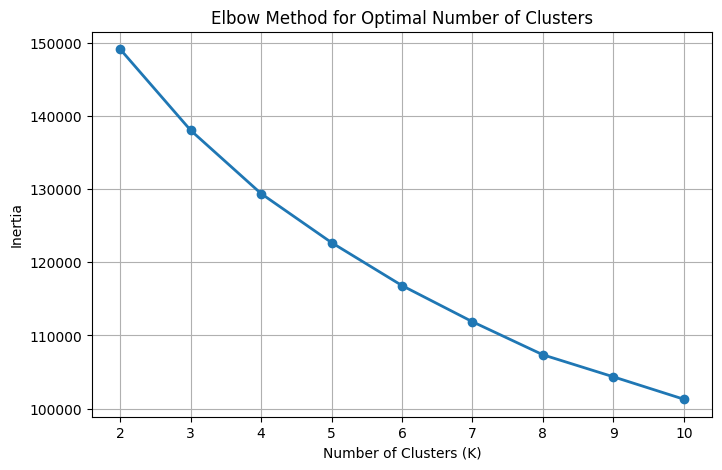

In [60]:
# =============================================================================
# Elbow Method
# =============================================================================

print("=" * 80)
print("ELBOW METHOD")
print("=" * 80)

k_values = range(2, 11)
inertia = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linewidth=2)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True)

# Save figure
plt.savefig(
    "outputs/Assignment2_Elbow_Method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

SILHOUETTE ANALYSIS

Optimal Number of Clusters: 8
Best Silhouette Score: 0.0991


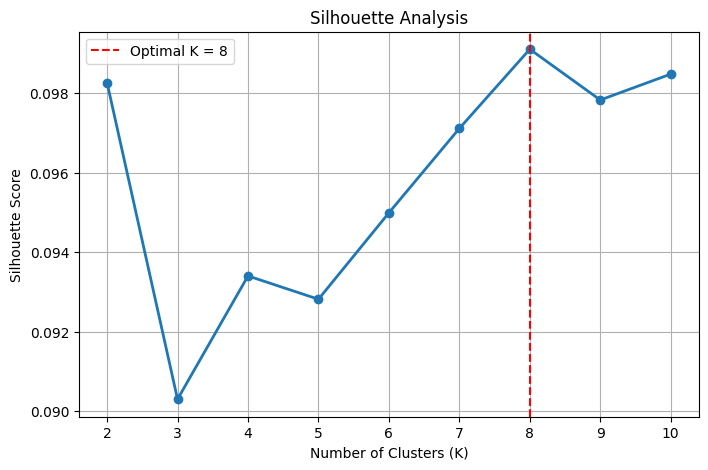

In [61]:
# =============================================================================
# Silhouette Analysis
# =============================================================================

print("=" * 80)
print("SILHOUETTE ANALYSIS")
print("=" * 80)

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster_scaled)

    score = silhouette_score(
        X_cluster_scaled,
        labels
    )

    silhouette_scores.append(score)

# Determine optimal K
optimal_k = range(2, 11)[np.argmax(silhouette_scores)]

print(f"\nOptimal Number of Clusters: {optimal_k}")
print(f"Best Silhouette Score: {max(silhouette_scores):.4f}")

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o',
    linewidth=2
)

plt.axvline(
    optimal_k,
    color='red',
    linestyle='--',
    label=f'Optimal K = {optimal_k}'
)

plt.title("Silhouette Analysis")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2,11))
plt.legend()
plt.grid(True)

plt.savefig(
    "outputs/Assignment2_Silhouette_Sweep.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [62]:
# =============================================================================
# K-Means Clustering
# =============================================================================

print("=" * 80)
print("K-MEANS CLUSTERING")
print("=" * 80)

# Train K-Means model
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_cluster_scaled)

# Evaluate clustering performance
kmeans_silhouette = silhouette_score(
    X_cluster_scaled,
    kmeans_labels
)

kmeans_dbi = davies_bouldin_score(
    X_cluster_scaled,
    kmeans_labels
)

kmeans_chi = calinski_harabasz_score(
    X_cluster_scaled,
    kmeans_labels
)

print(f"Number of Clusters : {optimal_k}")
print(f"Silhouette Score   : {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin     : {kmeans_dbi:.4f}")
print(f"Calinski-Harabasz  : {kmeans_chi:.4f}")

# Store cluster labels
cluster_results = cluster_features.copy()
cluster_results["KMeans_Cluster"] = kmeans_labels

# Save clustered dataset
cluster_results.to_csv(
    "outputs/reports/Assignment2_KMeans_Clusters.csv",
    index=False
)


K-MEANS CLUSTERING
Number of Clusters : 8
Silhouette Score   : 0.0991
Davies-Bouldin     : 1.8002
Calinski-Harabasz  : 1837.0641


In [63]:
# =============================================================================
# Agglomerative Clustering Model
# =============================================================================

print("=" * 80)
print("AGGLOMERATIVE CLUSTERING MODEL")
print("=" * 80)

# Train Agglomerative Clustering model
agglomerative = AgglomerativeClustering(
    n_clusters=optimal_k,
    linkage="ward"
)

agglomerative_labels = agglomerative.fit_predict(X_cluster_scaled)

print("Agglomerative Clustering model trained successfully.")

# Store cluster labels
cluster_results["Agglomerative_Cluster"] = agglomerative_labels

print(f"Number of clusters: {optimal_k}")
print(f"Samples clustered: {len(agglomerative_labels)}")

AGGLOMERATIVE CLUSTERING MODEL
Agglomerative Clustering model trained successfully.
Number of clusters: 8
Samples clustered: 23671


In [64]:
# =============================================================================
# Agglomerative Clustering Evaluation
# =============================================================================

print("=" * 80)
print("AGGLOMERATIVE CLUSTERING EVALUATION")
print("=" * 80)

# Calculate evaluation metrics
agg_silhouette = silhouette_score(
    X_cluster_scaled,
    agglomerative_labels
)

agg_davies = davies_bouldin_score(
    X_cluster_scaled,
    agglomerative_labels
)

agg_calinski = calinski_harabasz_score(
    X_cluster_scaled,
    agglomerative_labels
)

print(f"Silhouette Score       : {agg_silhouette:.4f}")
print(f"Davies-Bouldin Index   : {agg_davies:.4f}")
print(f"Calinski-Harabasz Index: {agg_calinski:.4f}")

# Save clustered dataset
cluster_results.to_csv(
    "outputs/reports/Assignment2_Agglomerative_Clusters.csv",
    index=False
)


AGGLOMERATIVE CLUSTERING EVALUATION
Silhouette Score       : 0.0171
Davies-Bouldin Index   : 2.5359
Calinski-Harabasz Index: 1050.6739


In [65]:
# =============================================================================
# DBSCAN Clustering Model
# =============================================================================

print("=" * 80)
print("DBSCAN CLUSTERING MODEL")
print("=" * 80)

# Train DBSCAN model
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_cluster_scaled)

# Store cluster labels
cluster_results["DBSCAN_Cluster"] = dbscan_labels

# Number of clusters (excluding noise)
num_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
num_noise = list(dbscan_labels).count(-1)

print("DBSCAN model trained successfully.")
print(f"Clusters found : {num_clusters}")
print(f"Noise points   : {num_noise}")

DBSCAN CLUSTERING MODEL
DBSCAN model trained successfully.
Clusters found : 332
Noise points   : 11543


In [66]:
# =============================================================================
# DBSCAN Evaluation
# =============================================================================

print("=" * 80)
print("DBSCAN EVALUATION")
print("=" * 80)

# Evaluate only if DBSCAN produced at least two valid clusters
unique_clusters = set(dbscan_labels)

if len(unique_clusters - {-1}) >= 2:

    dbscan_silhouette = silhouette_score(
        X_cluster_scaled,
        dbscan_labels
    )

    dbscan_davies = davies_bouldin_score(
        X_cluster_scaled,
        dbscan_labels
    )

    dbscan_calinski = calinski_harabasz_score(
        X_cluster_scaled,
        dbscan_labels
    )

else:

    dbscan_silhouette = np.nan
    dbscan_davies = np.nan
    dbscan_calinski = np.nan

    print("DBSCAN did not produce enough clusters for evaluation.")

print(f"Silhouette Score       : {dbscan_silhouette}")
print(f"Davies-Bouldin Index   : {dbscan_davies}")
print(f"Calinski-Harabasz Index: {dbscan_calinski}")

# Save clustered dataset
cluster_results.to_csv(
    "outputs/reports/Assignment2_DBSCAN_Clusters.csv",
    index=False
)


DBSCAN EVALUATION
Silhouette Score       : -0.5024570303217388
Davies-Bouldin Index   : 1.6746690940758509
Calinski-Harabasz Index: 6.844688476559634


In [67]:
# =============================================================================
# Clustering Models Comparison
# =============================================================================

print("=" * 80)
print("CLUSTERING MODELS COMPARISON")
print("=" * 80)

# Create comparison table
clustering_results = pd.DataFrame({
    "Model": [
        "K-Means",
        "Agglomerative Clustering",
        "DBSCAN"
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        agg_silhouette,
        dbscan_silhouette
    ],
    "Davies-Bouldin Index": [
        kmeans_dbi,
        agg_davies,
        dbscan_davies
    ],
    "Calinski-Harabasz Index": [
        kmeans_chi,
        agg_calinski,
        dbscan_calinski
    ]
})

# Display results
display(clustering_results)

# Save comparison table
clustering_results.to_csv(
    "outputs/reports/Assignment2_Cluster_Metrics.csv",
    index=False
)


CLUSTERING MODELS COMPARISON


,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,0.099103,1.800197,1837.064110
1,Agglomerative Clustering,0.017075,2.535941,1050.673896
2,DBSCAN,-0.502457,1.674669,6.844688


In [68]:
# =============================================================================
# Best Clustering Model
# =============================================================================

print("=" * 80)
print("BEST CLUSTERING MODEL")
print("=" * 80)

# Highest Silhouette Score
best_model = clustering_results.loc[
    clustering_results["Silhouette Score"].idxmax()
]

print(f"Best Clustering Model : {best_model['Model']}")
print(f"Silhouette Score      : {best_model['Silhouette Score']:.4f}")
print(f"Davies-Bouldin Index  : {best_model['Davies-Bouldin Index']:.4f}")
print(f"Calinski-Harabasz     : {best_model['Calinski-Harabasz Index']:.4f}")

print("\nInterpretation:")
print("- Higher Silhouette Score indicates better cluster separation.")
print("- Lower Davies-Bouldin Index indicates better clustering.")
print("- Higher Calinski-Harabasz Index indicates denser, well-separated clusters.")

BEST CLUSTERING MODEL
Best Clustering Model : K-Means
Silhouette Score      : 0.0991
Davies-Bouldin Index  : 1.8002
Calinski-Harabasz     : 1837.0641

Interpretation:
- Higher Silhouette Score indicates better cluster separation.
- Lower Davies-Bouldin Index indicates better clustering.
- Higher Calinski-Harabasz Index indicates denser, well-separated clusters.


In [69]:
# =============================================================================
# Principal Component Analysis (PCA)
# =============================================================================

print("=" * 80)
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("=" * 80)

# Reduce feature space to two principal components
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_cluster_scaled)

print("PCA completed successfully.")
print(f"Original Feature Dimensions : {X_cluster_scaled.shape[1]}")
print(f"Reduced Feature Dimensions  : {X_pca.shape[1]}")

# Explained variance
explained_variance = pca.explained_variance_ratio_

print("\nExplained Variance Ratio")
print(f"PC1 : {explained_variance[0]:.4f}")
print(f"PC2 : {explained_variance[1]:.4f}")
print(f"Total Explained Variance : {explained_variance.sum():.4f}")

# Create PCA DataFrame
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1]
})


PRINCIPAL COMPONENT ANALYSIS (PCA)
PCA completed successfully.
Original Feature Dimensions : 7
Reduced Feature Dimensions  : 2

Explained Variance Ratio
PC1 : 0.1462
PC2 : 0.1444
Total Explained Variance : 0.2906


PCA VISUALIZATION - K-MEANS


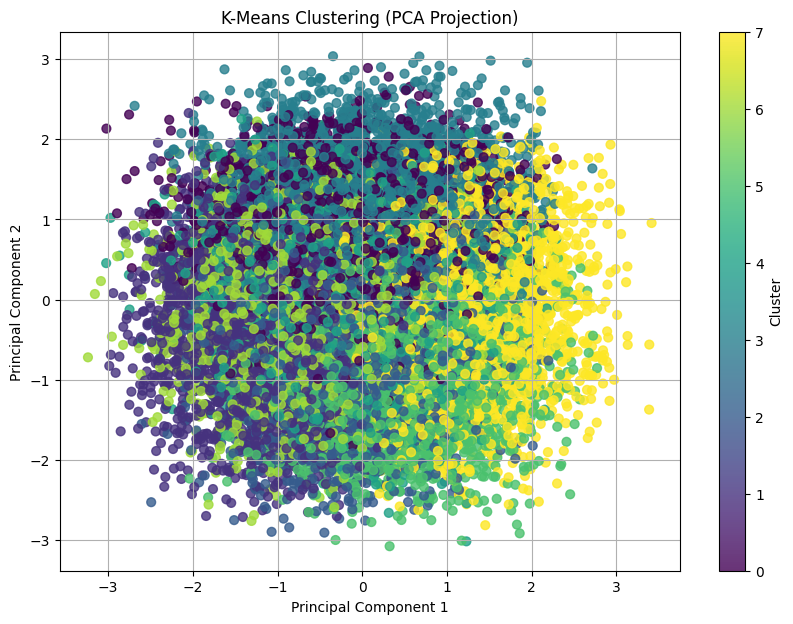

In [70]:
# =============================================================================
# PCA Visualization - K-Means
# =============================================================================

print("=" * 80)
print("PCA VISUALIZATION - K-MEANS")
print("=" * 80)

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=kmeans_labels,
    cmap="viridis",
    s=40,
    alpha=0.8
)

plt.title("K-Means Clustering (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter, label="Cluster")

plt.grid(True)

plt.savefig(
    "outputs/Assignment2_KMeans_PCA.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


PCA VISUALIZATION - AGGLOMERATIVE CLUSTERING


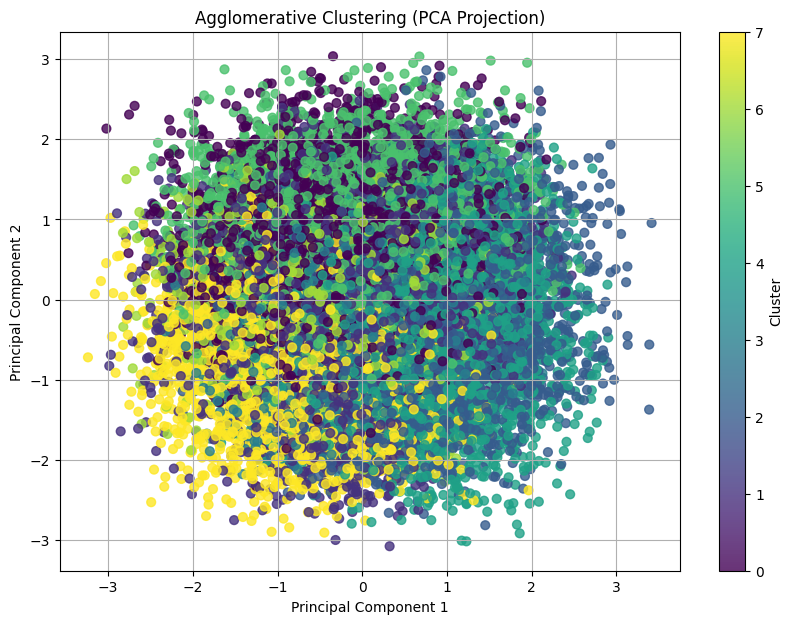

In [71]:
# =============================================================================
# PCA Visualization - Agglomerative Clustering
# =============================================================================

print("=" * 80)
print("PCA VISUALIZATION - AGGLOMERATIVE CLUSTERING")
print("=" * 80)

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=agglomerative_labels,
    cmap="viridis",
    s=40,
    alpha=0.8
)

plt.title("Agglomerative Clustering (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter, label="Cluster")

plt.grid(True)

plt.savefig(
    "outputs/Assignment2_Agglomerative_PCA.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


PCA VISUALIZATION - DBSCAN


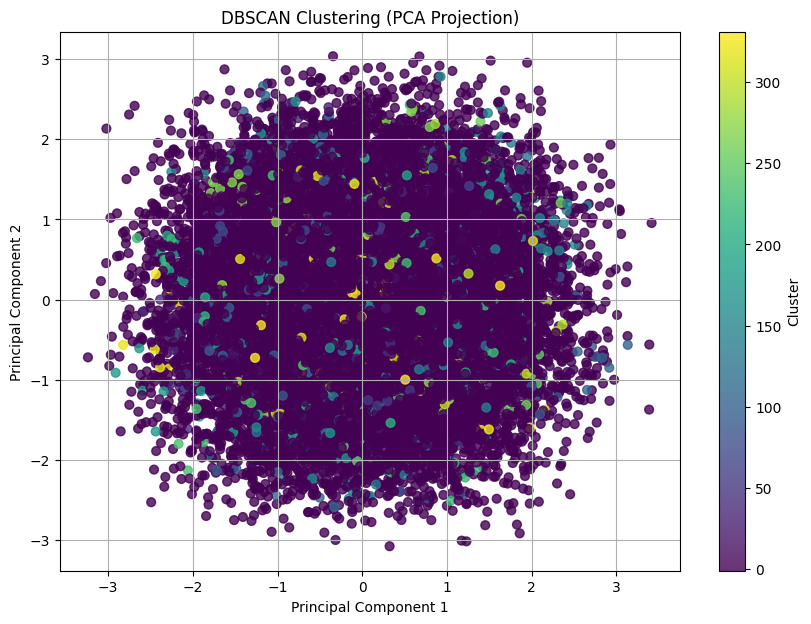

In [72]:
# =============================================================================
# PCA Visualization - DBSCAN
# =============================================================================

print("=" * 80)
print("PCA VISUALIZATION - DBSCAN")
print("=" * 80)

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=dbscan_labels,
    cmap="viridis",
    s=40,
    alpha=0.8
)

plt.title("DBSCAN Clustering (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter, label="Cluster")

plt.grid(True)

plt.savefig(
    "outputs/Assignment2_DBSCAN_PCA.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
# =============================================================================
# Outcome 4 – Reinforcement Learning
# =============================================================================
import random
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim

np.random.seed(42)
random.seed(42)
torch.manual_seed(42)


In [74]:
# =============================================================================
# Cloud Resource Scheduling Environment (MDP)
# =============================================================================

print("=" * 80)
print("CLOUD RESOURCE SCHEDULING ENVIRONMENT")
print("=" * 80)

class CloudEnvironment:

    def __init__(self):

        self.max_cpu = 100
        self.max_memory = 100
        self.max_steps = 100

        self.reset()

    def reset(self):

        self.cpu = np.random.randint(30, 70)
        self.memory = np.random.randint(30, 70)

        self.steps = 0

        state = np.array(
            [self.cpu, self.memory],
            dtype=np.float32
        )

        return state

    def step(self, action):

        reward = 0

        # Actions
        # 0 = Allocate Resources
        # 1 = Release Resources
        # 2 = Do Nothing

        workload = np.random.randint(-15, 16)

        if action == 0:
            self.cpu = min(self.max_cpu, self.cpu + 10)
            self.memory = min(self.max_memory, self.memory + 10)

        elif action == 1:
            self.cpu = max(0, self.cpu - 10)
            self.memory = max(0, self.memory - 10)

        elif action == 2:
            pass

        self.cpu = np.clip(self.cpu + workload, 0, self.max_cpu)
        self.memory = np.clip(self.memory + workload, 0, self.max_memory)

        # Reward Function
        if self.cpu < 85 and self.memory < 85:
            reward = 10
        else:
            reward = -20

        self.steps += 1

        done = self.steps >= self.max_steps

        state = np.array(
            [self.cpu, self.memory],
            dtype=np.float32
        )

        return state, reward, done

env = CloudEnvironment()

print("MDP Definition")

print("State  : CPU Usage, Memory Usage")
print("Actions: Allocate, Release, Maintain")
print("Reward : +10 Efficient Allocation | -20 SLA Violation")
print("Policy : Learned by Reinforcement Learning Agent")

CLOUD RESOURCE SCHEDULING ENVIRONMENT
MDP Definition
State  : CPU Usage, Memory Usage
Actions: Allocate, Release, Maintain
Reward : +10 Efficient Allocation | -20 SLA Violation
Policy : Learned by Reinforcement Learning Agent


In [75]:
# =============================================================================
# Q-Learning Agent
# =============================================================================

print("=" * 80)
print("Q-LEARNING AGENT")
print("=" * 80)

# Hyperparameters
learning_rate = 0.1
discount_factor = 0.95
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 500

# Q-Table
q_table = defaultdict(lambda: np.zeros(3))

q_learning_rewards = []
q_learning_sla = []

# Discretize state
def discretize_state(state):

    cpu = int(state[0] // 10)
    memory = int(state[1] // 10)

    return (cpu, memory)

for episode in range(episodes):

    state = discretize_state(env.reset())

    done = False
    total_reward = 0
    sla_violations = 0

    while not done:

        # Epsilon-Greedy Policy
        if np.random.rand() < epsilon:
            action = np.random.randint(3)
        else:
            action = np.argmax(q_table[state])

        next_state, reward, done = env.step(action)

        next_state = discretize_state(next_state)

        # Q-Learning Update
        old_value = q_table[state][action]

        next_max = np.max(q_table[next_state])

        q_table[state][action] = old_value + learning_rate * (
            reward +
            discount_factor * next_max -
            old_value
        )

        total_reward += reward

        if reward < 0:
            sla_violations += 1

        state = next_state

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    q_learning_rewards.append(total_reward)

    q_learning_sla.append(
        (sla_violations / env.max_steps) * 100
    )


Q-LEARNING AGENT


Q-LEARNING EVALUATION
Average Reward      : 944.08
Reward Std Dev      : 186.60
SLA Violation Rate  : 1.86%


,Agent,Mean Reward,SLA Violation (%)
0,Q-Learning,944.08,1.864


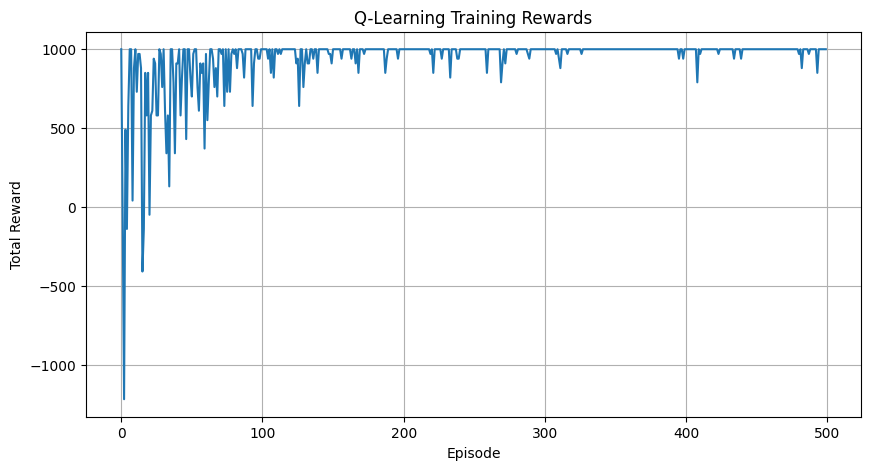

In [76]:
# =============================================================================
# Q-Learning Evaluation
# =============================================================================

print("=" * 80)
print("Q-LEARNING EVALUATION")
print("=" * 80)

q_learning_mean_reward = np.mean(q_learning_rewards)
q_learning_std_reward = np.std(q_learning_rewards)
q_learning_mean_sla = np.mean(q_learning_sla)

print(f"Average Reward      : {q_learning_mean_reward:.2f}")
print(f"Reward Std Dev      : {q_learning_std_reward:.2f}")
print(f"SLA Violation Rate  : {q_learning_mean_sla:.2f}%")

# Results DataFrame
q_learning_results = pd.DataFrame({

    "Agent": ["Q-Learning"],

    "Mean Reward": [q_learning_mean_reward],

    "SLA Violation (%)": [q_learning_mean_sla]

})

display(q_learning_results)

# Save results
q_learning_results.to_csv(
    "outputs/reports/Assignment2_Q_Learning.csv",
    index=False
)

# Save Q-Table
import pickle

with open(
    "outputs/models/Assignment2_Q_Table.pkl",
    "wb"
) as file:

    pickle.dump(dict(q_table), file)

# Training Curve
plt.figure(figsize=(10,5))

plt.plot(q_learning_rewards)

plt.title("Q-Learning Training Rewards")

plt.xlabel("Episode")

plt.ylabel("Total Reward")

plt.grid(True)

plt.savefig(
    "outputs/Assignment2_Q_Learning_Training.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [77]:
# =============================================================================
# Deep Q-Network (DQN) Training
# =============================================================================
from collections import deque

class DQN(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)


# Hyperparameters
learning_rate = 0.001
gamma = 0.99

epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05

episodes = 1000
batch_size = 64
memory_size = 10000
target_update = 20

memory = deque(maxlen=memory_size)

policy_net = DQN()
target_net = DQN()

target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

dqn_rewards = []
dqn_sla = []


def train_batch():

    if len(memory) < batch_size:
        return

    batch = random.sample(memory, batch_size)

    states = torch.FloatTensor([b[0] for b in batch])
    actions = torch.LongTensor([b[1] for b in batch]).unsqueeze(1)
    rewards = torch.FloatTensor([b[2] for b in batch])
    next_states = torch.FloatTensor([b[3] for b in batch])
    dones = torch.FloatTensor([b[4] for b in batch])

    current_q = policy_net(states).gather(1, actions).squeeze()

    with torch.no_grad():
        next_q = target_net(next_states).max(1)[0]

    target_q = rewards + gamma * next_q * (1 - dones)

    loss = criterion(current_q, target_q)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


for episode in range(episodes):

    state = env.reset()

    total_reward = 0
    sla = 0
    done = False

    while not done:

        if np.random.rand() < epsilon:
            action = np.random.randint(3)
        else:
            with torch.no_grad():
                action = torch.argmax(
                    policy_net(torch.FloatTensor(state))
                ).item()

        next_state, reward, done = env.step(action)

        memory.append(
            (
                state,
                action,
                reward,
                next_state,
                float(done)
            )
        )

        train_batch()

        total_reward += reward

        if reward < 0:
            sla += 1

        state = next_state

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

    if episode % target_update == 0:
        target_net.load_state_dict(
            policy_net.state_dict()
        )

    dqn_rewards.append(total_reward)

    dqn_sla.append(
        sla / env.max_steps * 100
    )

DEEP Q-NETWORK EVALUATION
Average Reward      : 945.25
Reward Std Dev      : 146.20
SLA Violation Rate  : 1.82%


,Agent,Mean Reward,SLA Violation (%)
0,Deep Q-Network,945.25,1.825


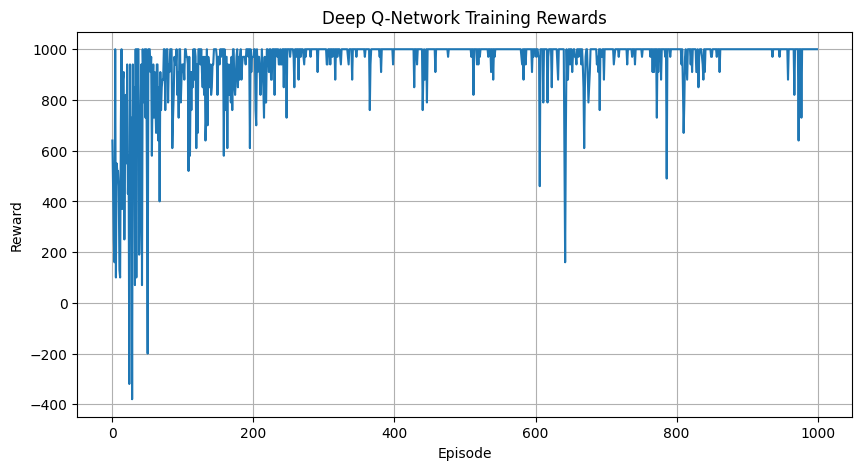

In [78]:
# =============================================================================
# Deep Q-Network Evaluation
# =============================================================================

print("=" * 80)
print("DEEP Q-NETWORK EVALUATION")
print("=" * 80)

dqn_mean_reward = np.mean(dqn_rewards)
dqn_std_reward = np.std(dqn_rewards)
dqn_mean_sla = np.mean(dqn_sla)

print(f"Average Reward      : {dqn_mean_reward:.2f}")
print(f"Reward Std Dev      : {dqn_std_reward:.2f}")
print(f"SLA Violation Rate  : {dqn_mean_sla:.2f}%")

dqn_results = pd.DataFrame({
    "Agent": ["Deep Q-Network"],
    "Mean Reward": [dqn_mean_reward],
    "SLA Violation (%)": [dqn_mean_sla]
})

display(dqn_results)

dqn_results.to_csv(
    "outputs/reports/Assignment2_DQN.csv",
    index=False
)

torch.save(
    policy_net.state_dict(),
    "outputs/models/Assignment2_DQN_Model.pth"
)

plt.figure(figsize=(10,5))
plt.plot(dqn_rewards)
plt.title("Deep Q-Network Training Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)

plt.savefig(
    "outputs/Assignment2_DQN_Training.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [79]:
# =============================================================================
# Random Baseline Agent
# =============================================================================

print("=" * 80)
print("RANDOM BASELINE AGENT")
print("=" * 80)

episodes = 500

random_rewards = []
random_sla_violations = []

for episode in range(episodes):

    state = env.reset()

    total_reward = 0
    sla_violations = 0

    done = False

    while not done:

        # Randomly choose an action
        action = np.random.randint(0, 3)

        next_state, reward, done = env.step(action)

        total_reward += reward

        if reward < 0:
            sla_violations += 1

        state = next_state

    random_rewards.append(total_reward)

    random_sla_violations.append(
        (sla_violations / env.max_steps) * 100
    )

random_mean_reward = np.mean(random_rewards)
random_std_reward = np.std(random_rewards)

random_mean_sla = np.mean(random_sla_violations)

print(f"Average Reward      : {random_mean_reward:.2f}")
print(f"Reward Std Dev      : {random_std_reward:.2f}")
print(f"SLA Violation Rate  : {random_mean_sla:.2f}%")

RANDOM BASELINE AGENT
Average Reward      : 410.08
Reward Std Dev      : 438.27
SLA Violation Rate  : 19.66%


RANDOM BASELINE EVALUATION


,Agent,Mean Reward,SLA Violation (%)
0,Random Policy,410.08,19.664


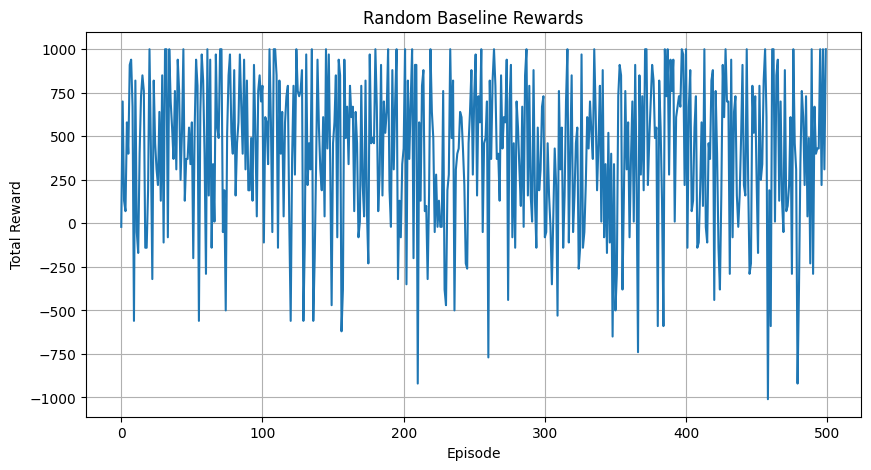

In [80]:
# =============================================================================
# Random Baseline Evaluation
# =============================================================================

print("=" * 80)
print("RANDOM BASELINE EVALUATION")
print("=" * 80)

random_results = pd.DataFrame({
    "Agent": ["Random Policy"],
    "Mean Reward": [random_mean_reward],
    "SLA Violation (%)": [random_mean_sla]
})

display(random_results)

# Save results
random_results.to_csv(
    "outputs/reports/Assignment2_Random_Baseline.csv",
    index=False
)

# Plot episode rewards
plt.figure(figsize=(10,5))

plt.plot(random_rewards)

plt.title("Random Baseline Rewards")
plt.xlabel("Episode")
plt.ylabel("Total Reward")

plt.grid(True)

plt.savefig(
    "outputs/Assignment2_Random_Baseline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [81]:
# =============================================================================
# CROSS-STAGE LEADERBOARD
# =============================================================================

print("=" * 80)
print("CROSS-STAGE LEADERBOARD")
print("=" * 80)

# ============================================================================
# Best Regression Model
# ============================================================================

best_regression = reg_df.loc[
    reg_df["R²"].idxmax()
]

# ============================================================================
# Best Classification Model
# ============================================================================

best_classification = clf_df.loc[
    clf_df["F1"].idxmax()
]

# ============================================================================
# Best Clustering Model
# ============================================================================

best_cluster = clustering_results.loc[
    clustering_results["Silhouette Score"].idxmax()
]

# ============================================================================
# Reinforcement Learning Results
# ============================================================================

rl_results = pd.DataFrame({

    "Agent": [
        "Random Policy",
        "Q-Learning",
        "Deep Q-Network"
    ],

    "Mean Reward": [
        random_mean_reward,
        q_learning_mean_reward,
        dqn_mean_reward
    ],

    "SLA Violation (%)": [
        random_mean_sla,
        q_learning_mean_sla,
        dqn_mean_sla
    ]

})

best_rl = rl_results.loc[
    rl_results["Mean Reward"].idxmax()
]

# ============================================================================
# Leaderboard
# ============================================================================

leaderboard = pd.DataFrame({

    "Stage": [

        "Regression",

        "Classification",

        "Clustering",

        "Reinforcement Learning"

    ],

    "Best Model": [

        best_regression["Model"],

        best_classification["Model"],

        best_cluster["Model"],

        best_rl["Agent"]

    ],

    "Primary Metric": [

        best_regression["R²"],

        best_classification["F1"],

        best_cluster["Silhouette Score"],

        best_rl["Mean Reward"]

    ]

})

display(leaderboard)

leaderboard.to_csv(
    "outputs/reports/Assignment2_Cross_Stage_Leaderboard.csv",
    index=False
)


CROSS-STAGE LEADERBOARD


,Stage,Best Model,Primary Metric
0,Regression,Linear Regression,1.000000
1,Classification,Random Forest,1.000000
2,Clustering,K-Means,0.099103
3,Reinforcement Learning,Deep Q-Network,945.250000


In [82]:
# =============================================================================
# MASTER JSON REPORT
# =============================================================================

print("=" * 80)
print("MASTER JSON REPORT")
print("=" * 80)

import json

master_report = {

    "Regression": {

        "Best Model": best_regression["Model"],

        "R2 Score": float(best_regression["R²"]),

        "RMSE": float(best_regression["RMSE"]),

        "MAE": float(best_regression["MAE"])

    },

    "Classification": {

        "Best Model": best_classification["Model"],

        "Accuracy": float(best_classification["Accuracy"]),

        "F1 Score": float(best_classification["F1"]),

        "Precision": float(best_classification["Precision"]),

        "Recall": float(best_classification["Recall"])

    },

    "Clustering": {

        "Best Model": best_cluster["Model"],

        "Silhouette Score": float(best_cluster["Silhouette Score"]),

        "Davies-Bouldin Index": float(best_cluster["Davies-Bouldin Index"]),

        "Calinski-Harabasz Index": float(best_cluster["Calinski-Harabasz Index"])

    },

    "Reinforcement Learning": {

        "Best Agent": best_rl["Agent"],

        "Mean Reward": float(best_rl["Mean Reward"]),

        "SLA Violation (%)": float(best_rl["SLA Violation (%)"])

    }

}

with open(
    "outputs/reports/Assignment2_Master_Report.json",
    "w"
) as file:

    json.dump(
        master_report,
        file,
        indent=4
    )

print(json.dumps(master_report, indent=4))


MASTER JSON REPORT
{
    "Regression": {
        "Best Model": "Linear Regression",
        "R2 Score": 1.0,
        "RMSE": 1.2178830624992355e-13,
        "MAE": 9.908446159649512e-14
    },
    "Classification": {
        "Best Model": "Random Forest",
        "Accuracy": 1.0,
        "F1 Score": 1.0,
        "Precision": 1.0,
        "Recall": 1.0
    },
    "Clustering": {
        "Best Model": "K-Means",
        "Silhouette Score": 0.09910313348570228,
        "Davies-Bouldin Index": 1.8001966729261367,
        "Calinski-Harabasz Index": 1837.0641098203123
    },
    "Reinforcement Learning": {
        "Best Agent": "Deep Q-Network",
        "Mean Reward": 945.25,
        "SLA Violation (%)": 1.825
    }
}
